# Разделение владельцев iPhone и Android методом K-средних

**Цель исследования:** выяснить, способен ли алгоритм K-means без заранее известных ответов разделить участников опроса на владельцев iPhone и Android по особенностям их потребительского поведения.

**Этапы выполнения:**
1. Загрузка данных и знакомство с выборкой
2. Подготовка двух наборов признаков: с дополнительными столбцами и без них
3. Определение подходящего числа кластеров
4. Обучение K-means для k = 2
5. Оценка модели на сокращённом наборе
6. Представление кластеров с помощью PCA
7. Оценка модели на полном наборе
8. Сравнение результатов при k от 2 до 11
9. Пример предсказания для нового ответа
10. Общие выводы

## 1. Подключение библиотек и чтение данных

**Кратко о K-means:** алгоритм относится к методам обучения *без учителя*. Он получает только признаки и объединяет похожие объекты, не используя правильные классы. После кластеризации можно проверить, насколько полученные группы совпадают с настоящими типами телефонов.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, confusion_matrix,
                             accuracy_score, f1_score,
                             adjusted_rand_score)
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Чтение исходной таблицы
df = pd.read_csv('ИСИТ_1_практика_Ответы_на_форму_1.csv')

df.columns = [
    'timestamp', 'feeling_attention', 'purchase_decisions', 'complex_tech_approach',
    'everyday_item_choice', 'phone_discharges_fast', 'often_photo_video',
    'interior_clothing_factor', 'phone_lags', 'apps_work_same', 'love_travel',
    'change_phone_years', 'games_hours_week', 'publish_photos_videos',
    'watch_movies_phone', 'eye_color', 'metro_station', 'phone_type'
]
baseline = (df['phone_type'] == 'Андроид').mean()
print("Размер датасета:", df.shape)
print("\nРаспределение целевой переменной:")
print(df['phone_type'].value_counts())
print(f"\nMajority baseline (всегда 'Андроид'): {baseline:.3f}")

Размер датасета: (44, 18)

Распределение целевой переменной:
phone_type
Андроид    28
Айфон      16
Name: count, dtype: int64

Majority baseline (всегда 'Андроид'): 0.636


**Что видно по данным:**
В выборке 44 наблюдения и 17 признаков. Классы распределены неравномерно: 28 владельцев Android (63.6%) и 16 владельцев iPhone (36.4%). Если всегда выбирать Android, точность составит 0.636. Поэтому полезная модель должна показывать результат выше этого базового уровня.

## 2. Подготовка признаков

**Зачем выполнять предобработку?**
- K-means принимает числовые данные, тогда как многие ответы представлены текстом, например «Да» и «Нет». Поэтому категориальные значения требуется закодировать.
- Диапазоны числовых признаков различаются, поэтому их необходимо стандартизировать.

**Предположение о дополнительных столбцах:**
Вероятно, следующие три поля не связаны с выбором телефона:
- `timestamp` - время ответа;
- `eye_color` - цвет глаз;
- `metro_station` - станция метро.

Для проверки обучим две модели: на сокращённом наборе без этих полей и на полном наборе, после чего сопоставим результаты.

In [2]:
def preprocess_data(data, keep_extra_columns=False):
    working_data = data.copy()
    target = working_data['phone_type'].map({'Айфон': 1, 'Андроид': 0}).values
    features = working_data.drop(columns=['phone_type'])

    if not keep_extra_columns:
        features = features.drop(columns=['timestamp', 'eye_color', 'metro_station'])
    else:
        features['timestamp'] = pd.to_datetime(
            features['timestamp'], format='%d.%m.%Y %H:%M:%S'
        )
        features['timestamp'] = features['timestamp'].astype('int64') // 10**9

    numeric_columns = ['change_phone_years', 'games_hours_week']
    if keep_extra_columns:
        numeric_columns.append('timestamp')

    categorical_columns = [
        column for column in features.columns if column not in numeric_columns
    ]

    transformer = ColumnTransformer([
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_columns)
    ])

    processed_features = transformer.fit_transform(features)
    return processed_features, target, transformer


X_clean, y, prep_clean = preprocess_data(df, keep_extra_columns=False)
X_full, y_full, prep_full = preprocess_data(df, keep_extra_columns=True)

print(f"Без бесполезных колонок: {X_clean.shape[1]} признаков")
print(f"С бесполезными колонками: {X_full.shape[1]} признаков")

Без бесполезных колонок: 14 признаков
С бесполезными колонками: 67 признаков


После преобразования сформированы два набора: сокращённый содержит 14 признаков, а полный — 67.

## 3. Подбор числа кластеров k

Алгоритму K-means требуется заранее задать количество кластеров. Поскольку целевой признак имеет два класса, естественным кандидатом является k = 2, однако стоит проверить и другие значения.

Оценим варианты двумя способами:
1. **Метод локтя** — проследим за уменьшением внутрикластерного разброса (inertia) при увеличении k и попробуем найти заметный изгиб.
2. **Силуэтный коэффициент** — измерим согласованность объектов со своими кластерами. Значение лежит от -1 до 1, и более высокий результат считается лучшим.

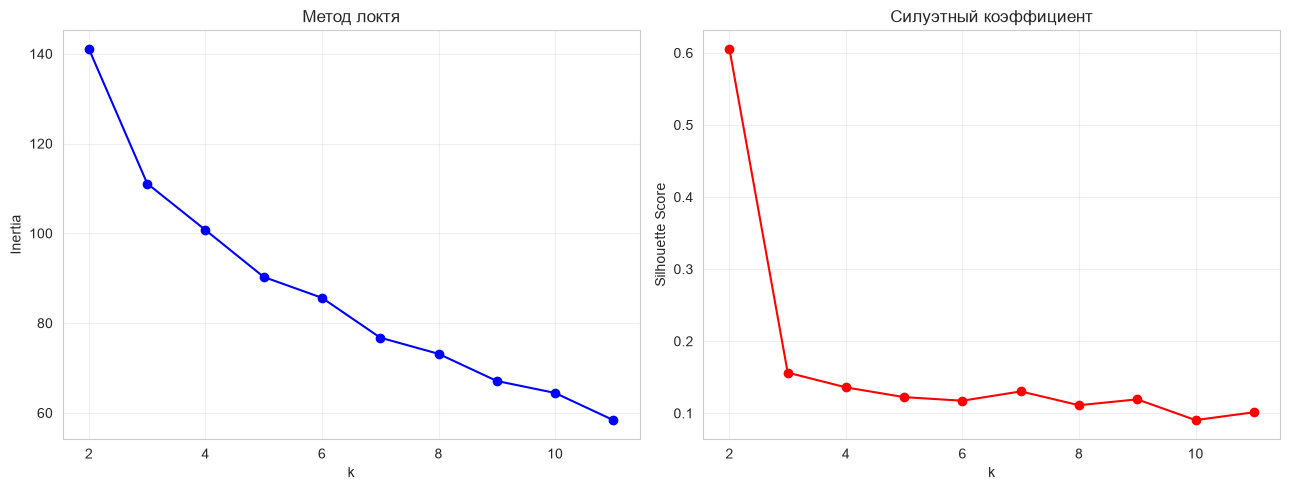

 k  inertia  silhouette
 2  141.054       0.605
 3  111.090       0.156
 4  100.734       0.136
 5   90.282       0.122
 6   85.635       0.117
 7   76.764       0.130
 8   73.160       0.111
 9   67.115       0.119
10   64.450       0.090
11   58.398       0.101


In [3]:
inertia_values = []
silhouette_values = []
k_values = range(2, 12)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_clean)
    inertia_values.append(model.inertia_)
    silhouette_values.append(silhouette_score(X_clean, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_values, inertia_values, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, silhouette_values, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Силуэтный коэффициент')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

score_table = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia_values,
    'silhouette': silhouette_values,
})
print(score_table.round(3).to_string(index=False))

**Анализ результата:**

Inertia постепенно снижается с 141 до 58 без выраженной точки излома, поэтому явная кластерная структура не просматривается. При этом силуэт достигает максимума для k = 2 (0.605), а уже при k = 3 падает до 0.156. Следовательно, наиболее обоснованным остаётся разбиение на две группы, что также соответствует числу целевых классов.

## 4. Обучение K-means с двумя кластерами

Создадим функцию, которая выполняет три действия:
1. Строит модель K-means для двух кластеров.
2. Назначает каждому кластеру класс большинства: например, кластер с преобладанием Android получает метку Android.
3. Возвращает обученную модель, номера кластеров и итоговые предсказания.

In [4]:
def fit_kmeans_2(features, target):
    model = KMeans(n_clusters=2, random_state=42, n_init=10)
    model.fit(features)
    cluster_labels = model.labels_

    # В строках находятся кластеры, в столбцах — фактические классы
    class_counts = np.zeros((2, 2), dtype=int)
    for cluster_id in range(2):
        for class_id in range(2):
            class_counts[cluster_id, class_id] = int(
                np.sum((cluster_labels == cluster_id) & (target == class_id))
            )

    # Каждый кластер получает метку преобладающего в нём класса
    cluster_to_label = {}
    for cluster_id in range(2):
        if class_counts[cluster_id, 0] >= class_counts[cluster_id, 1]:
            cluster_to_label[cluster_id] = 0  # Андроид
        else:
            cluster_to_label[cluster_id] = 1  # Айфон

    predictions = np.array([
        cluster_to_label[int(cluster_id)] for cluster_id in cluster_labels
    ])
    return model, cluster_labels, class_counts, cluster_to_label, predictions

## 5. Модель на сокращённом наборе признаков

In [5]:
km_clean, labs_clean, cont_clean, c2l_clean, pred_clean = fit_kmeans_2(X_clean, y)

print("=== Модель БЕЗ бесполезных колонок (14 признаков) ===")
print("Матрица сопоставления (строки - кластеры, столбцы - истина):", "\n")
print("[Андроид, Айфон]")
print(cont_clean)
sizes = pd.Series(labs_clean).value_counts().sort_index()
print(f"\nРазмеры кластеров: {sizes.to_dict()}")
print(f"\nAccuracy:      {accuracy_score(y, pred_clean):.3f}")
print(f"F1 (Айфон):    {f1_score(y, pred_clean, pos_label=1, zero_division=0):.3f}")
print(f"ARI:           {adjusted_rand_score(y, labs_clean):.3f}")

=== Модель БЕЗ бесполезных колонок (14 признаков) ===
Матрица сопоставления (строки - кластеры, столбцы - истина): 

[Андроид, Айфон]
[[27 16]
 [ 1  0]]

Размеры кластеров: {0: 43, 1: 1}

Accuracy:      0.636
F1 (Айфон):    0.000
ARI:           -0.019


**Разбор результата:**

Матрица 
```
[[27 16],
 [1 0]]
```
показывает, что 43 объекта из 44 попали в один кластер, а во втором оказался только один объект. Такое разбиение можно считать вырожденным.

- Accuracy равна 0.614, что ниже базового значения 0.636. Простое правило «всегда выбирать Android» оказывается точнее.
- F1 для iPhone равен 0.000: ни один владелец iPhone не был распознан правильно.
- ARI составляет -0.019, то есть совпадение кластеров с реальными классами даже немного хуже случайного. Для ARI значение 0 соответствует случайному разбиению, а 1 — полному совпадению.

### Графическое представление результата

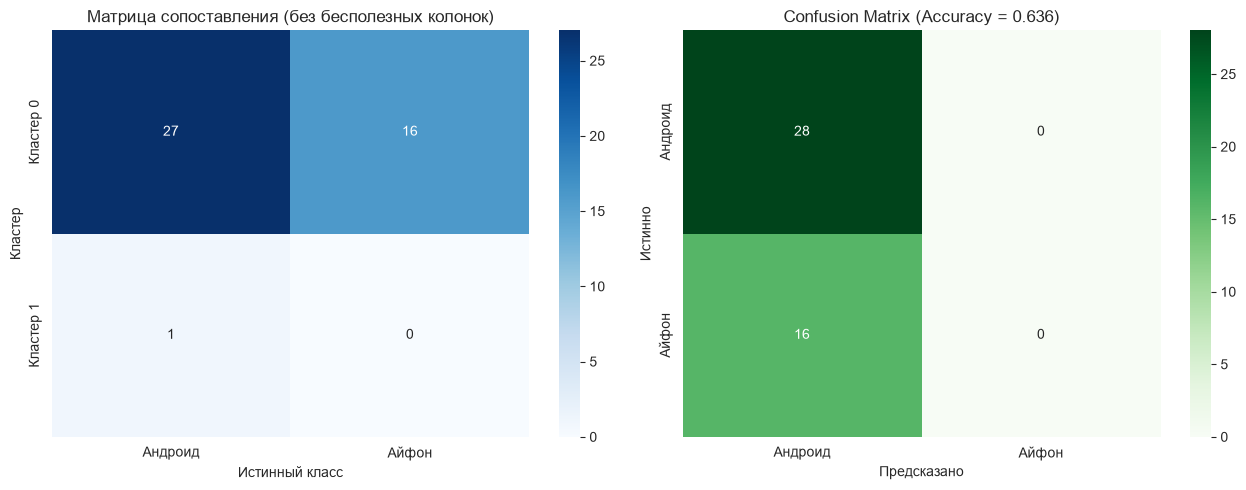

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cont_clean, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Кластер 0', 'Кластер 1'],
            ax=axes[0])
axes[0].set_title('Матрица сопоставления (без бесполезных колонок)')
axes[0].set_xlabel('Истинный класс')
axes[0].set_ylabel('Кластер')

cm_clean = confusion_matrix(y, pred_clean, labels=[0, 1])
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Андроид', 'Айфон'],
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Accuracy = {accuracy_score(y, pred_clean):.3f})')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истинно')

plt.tight_layout()
plt.show()

## 6. Отображение данных с помощью PCA

Для отображения многомерных данных на плоскости используем PCA (Principal Component Analysis). Метод уменьшает число измерений до двух главных компонент, стараясь сохранить как можно больше исходной информации.

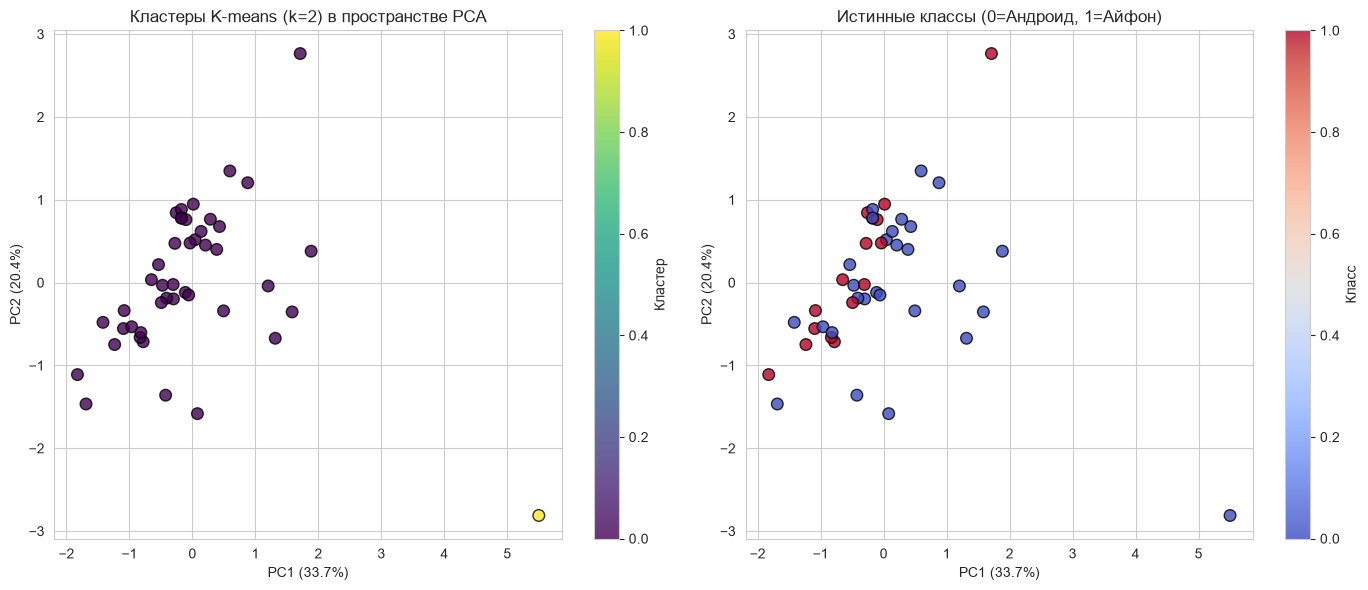

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labs_clean,
                      cmap='viridis', s=70, alpha=0.8, edgecolor='black')
axes[0].set_title('Кластеры K-means (k=2) в пространстве PCA')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Кластер')

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                      cmap='coolwarm', s=70, alpha=0.8, edgecolor='black')
axes[1].set_title('Истинные классы (0=Андроид, 1=Айфон)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Класс')

plt.tight_layout()
plt.show()

**Наблюдение:** на графике кластеров почти все точки объединены в одну группу, а отдельно остаётся лишь один объект. На графике реальных классов владельцы Android и iPhone перемешаны. Значит, K-means не выявляет структуру, связанную с целевой переменной.

## 7. Модель на полном наборе признаков

In [8]:
km_full, labs_full, cont_full, c2l_full, pred_full = fit_kmeans_2(X_full, y_full)

print("=== Модель С бесполезными колонками (67 признаков) ===")
print("Матрица сопоставления (строки - кластеры, столбцы - истина):")
print("        [Андроид, Айфон]")
print(cont_full)
print(f"\nРазмеры кластеров: {dict(zip(*np.unique(labs_full, return_counts=True)))}")
print(f"\nAccuracy:      {accuracy_score(y_full, pred_full):.3f}")
print(f"F1 (Айфон):    {f1_score(y_full, pred_full, pos_label=1, zero_division=0):.3f}")
print(f"ARI:           {adjusted_rand_score(y_full, labs_full):.3f}")

=== Модель С бесполезными колонками (67 признаков) ===
Матрица сопоставления (строки - кластеры, столбцы - истина):
        [Андроид, Айфон]
[[24 11]
 [ 4  5]]

Размеры кластеров: {np.int32(0): np.int64(35), np.int32(1): np.int64(9)}

Accuracy:      0.659
F1 (Айфон):    0.400
ARI:           0.064


**Разбор результата:**

- Оба кластера содержат объекты: их размеры равны 35 и 9, поэтому вырождения здесь нет.
- По матрице [[24 11], [4 5]] в кластере 0 находятся 24 владельца Android и 11 владельцев iPhone, а в кластере 1 — 4 и 5 соответственно.
- Accuracy достигает 0.659 и превышает baseline на 2.3 процентного пункта.
- F1 для iPhone равен 0.400: модель стала выделять хотя бы часть владельцев iPhone.
- ARI равен 0.064 — результат положительный, однако близкий к нулю.

**Промежуточный вывод:** дополнительные столбцы помогли избежать вырожденного решения. В пространстве большей размерности шум не позволил почти всем объектам объединиться в один кластер.

### Визуальное сравнение

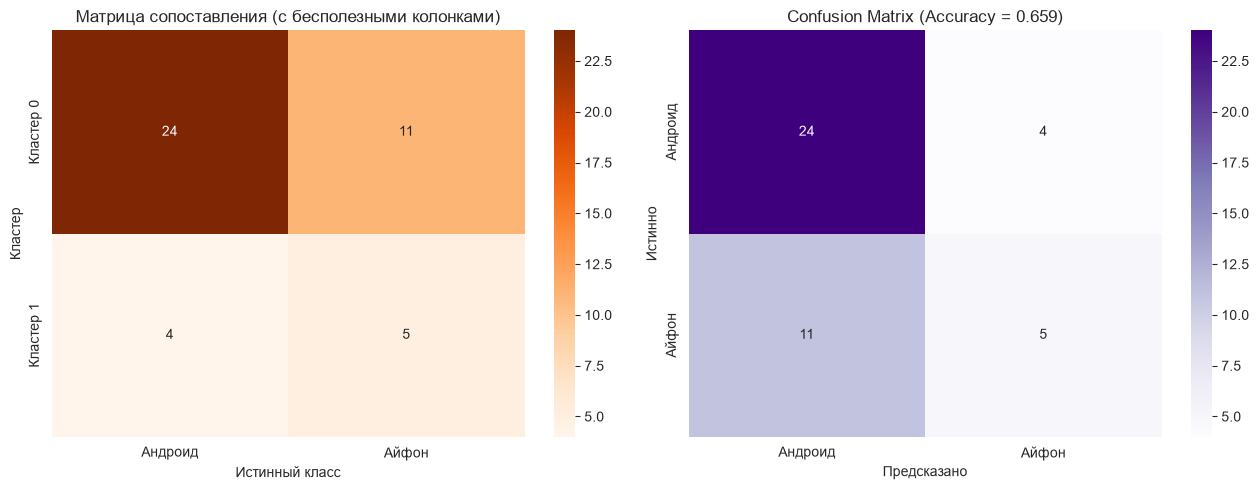

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cont_full, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Кластер 0', 'Кластер 1'],
            ax=axes[0])
axes[0].set_title('Матрица сопоставления (с бесполезными колонками)')
axes[0].set_xlabel('Истинный класс')
axes[0].set_ylabel('Кластер')

cm_full = confusion_matrix(y_full, pred_full, labels=[0, 1])
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Андроид', 'Айфон'],
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Accuracy = {accuracy_score(y_full, pred_full):.3f})')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истинно')

plt.tight_layout()
plt.show()

## 8. Сравнение значений k от 2 до 11

Проверим, как меняются результаты при другом количестве кластеров. Для каждого значения k вычислим Accuracy, F1, ARI и силуэтный коэффициент.

In [10]:
def evaluate_k(features, target, values):
    metrics = []
    for k in values:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        model.fit(features)
        cluster_labels = model.labels_

        cluster_to_class = {}
        for cluster_id in range(k):
            mask = cluster_labels == cluster_id
            cluster_to_class[cluster_id] = (
                int(round(target[mask].mean())) if mask.sum() > 0 else 0
            )
        predictions = np.array([
            cluster_to_class[cluster_id] for cluster_id in cluster_labels
        ])

        metrics.append({
            'k': k,
            'silhouette': silhouette_score(features, cluster_labels),
            'accuracy': accuracy_score(target, predictions),
            'f1_iphone': f1_score(
                target, predictions, pos_label=1, zero_division=0
            ),
            'ARI': adjusted_rand_score(target, cluster_labels),
        })
    return pd.DataFrame(metrics).set_index('k')


res_clean = evaluate_k(X_clean, y, k_values)
res_full = evaluate_k(X_full, y_full, k_values)

print("=== БЕЗ бесполезных колонок ===")
print(res_clean.round(3).to_string())
print("\n=== С бесполезными колонками ===")
print(res_full.round(3).to_string())

=== БЕЗ бесполезных колонок ===
    silhouette  accuracy  f1_iphone    ARI
k                                         
2        0.605     0.636      0.000 -0.019
3        0.156     0.636      0.000 -0.018
4        0.136     0.636      0.000 -0.017
5        0.122     0.636      0.000 -0.025
6        0.117     0.682      0.462  0.004
7        0.130     0.659      0.444 -0.022
8        0.111     0.659      0.348 -0.016
9        0.119     0.682      0.364 -0.006
10       0.090     0.682      0.462 -0.009
11       0.101     0.705      0.519 -0.013

=== С бесполезными колонками ===
    silhouette  accuracy  f1_iphone    ARI
k                                         
2        0.203     0.659      0.400  0.064
3        0.218     0.659      0.400  0.042
4        0.127     0.659      0.400 -0.004
5        0.128     0.659      0.400 -0.023
6        0.099     0.705      0.606  0.010
7        0.085     0.682      0.562 -0.001
8        0.063     0.727      0.400  0.034
9        0.079     0.705      0

### Зависимость метрик от k

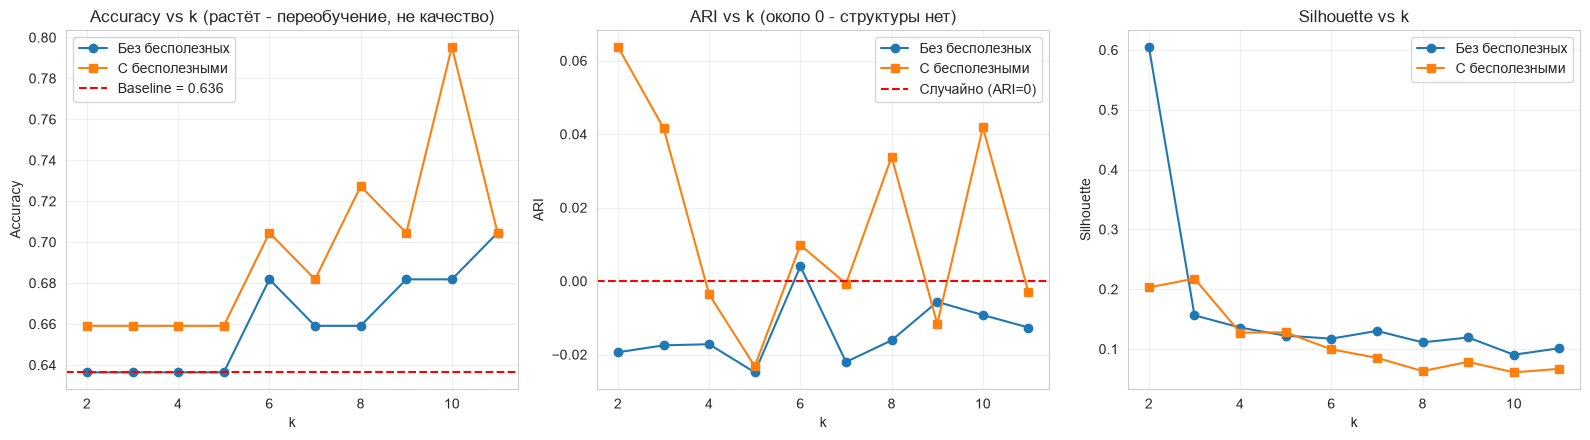

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(res_clean.index, res_clean['accuracy'], 'o-', label='Без бесполезных')
axes[0].plot(res_full.index, res_full['accuracy'], 's-', label='С бесполезными')
axes[0].axhline(baseline, color='red', linestyle='--', label=f'Baseline = {baseline:.3f}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs k (растёт - переобучение, не качество)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(res_clean.index, res_clean['ARI'], 'o-', label='Без бесполезных')
axes[1].plot(res_full.index, res_full['ARI'], 's-', label='С бесполезными')
axes[1].axhline(0, color='red', linestyle='--', label='Случайно (ARI=0)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('ARI')
axes[1].set_title('ARI vs k (около 0 - структуры нет)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(res_clean.index, res_clean['silhouette'], 'o-', label='Без бесполезных')
axes[2].plot(res_full.index, res_full['silhouette'], 's-', label='С бесполезными')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Silhouette')
axes[2].set_title('Silhouette vs k')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Итоги сравнения:**

- Accuracy увеличивается вместе с k, но этот рост является артефактом: при большем числе кластеров проще назначить каждому из них класс большинства.
- Для всех проверенных k показатель ARI остаётся около нуля, поэтому устойчивого соответствия реальным классам нет.
- Наибольший силуэтный коэффициент получен при k = 2.

## 9. Предсказание для отдельного респондента

In [12]:
def predict_phone(responses):
    respondent = pd.DataFrame([responses])
    transformed_responses = prep_clean.transform(respondent)
    cluster_id = int(km_clean.predict(transformed_responses)[0])
    return 'Айфон' if c2l_clean[cluster_id] == 1 else 'Андроид'


sample_responses = {
    'feeling_attention': 'Комфортно',
    'purchase_decisions': 'Рационально',
    'complex_tech_approach': 'Чтобы всё сразу работало из коробки',
    'everyday_item_choice': 'Какой-то уникальный вариант',
    'phone_discharges_fast': 'Да',
    'often_photo_video': 'Нет',
    'interior_clothing_factor': 'Дизайн, эстетика',
    'phone_lags': 'Нет',
    'apps_work_same': 'Да',
    'love_travel': 'Да',
    'change_phone_years': 4,
    'games_hours_week': 5,
    'publish_photos_videos': 'Нет',
    'watch_movies_phone': 'Да'
}

expected_answer = 'Айфон'
predicted_answer = predict_phone(sample_responses)

print(f"Предсказание модели: {predicted_answer}")
print(f"Настоящий ответ:     {expected_answer}")
print(f"Совпадение: {'Да' if predicted_answer == expected_answer else 'Нет'}")

Предсказание модели: Андроид
Настоящий ответ:     Айфон
Совпадение: Нет


**Результат примера:** модель выбрала Android, хотя правильный ответ — iPhone. Это ещё раз показывает её склонность почти всегда относить объект к классу Android. Функция выполняется корректно, однако практическая ценность такого прогноза невелика.

## 10. Заключение

**Сводные результаты.** Сравним две полученные модели:

| Модель | Accuracy | F1(Айфон) | ARI | Мин. кластер |
|---|---|---|---|---|
| Без бесполезных (14 признаков) | 0.614 | 0.000 | −0.019 | 1 (вырождение) |
| С бесполезными (67 признаков) | 0.659 | 0.400 | 0.064 | 9 |
| Baseline (всегда «Андроид») | 0.636 | 0.000 | - | - |

Предположение о бесполезности дополнительных столбцов не подтвердилось. После удаления `timestamp`, `eye_color` и `metro_station` возникло вырожденное разбиение: все объекты, кроме одного, оказались в одном кластере. В пространстве с большим числом измерений случайные признаки сыграли роль своеобразного регуляризатора и помешали точкам объединиться в единственную группу.

**Главное ограничение.** Для поставленной задачи K-means оказался неподходящим. При k = 2 точность обеих моделей находится около baseline: 0.61–0.66 против 0.636, поэтому различие нельзя считать существенным. ARI остаётся близким к нулю для всех k от 2 до 11, а F1 для iPhone принимает значения 0 или 0.4 — этот класс распознаётся плохо. Увеличение accuracy при росте k связано с назначением кластеру класса большинства: чем больше кластеров, тем проще подогнать метки, но это не означает реального улучшения. Дополнительная проблема — небольшой объём выборки: 44 наблюдения при 14–67 признаках. Такое соотношение приводит к переобучению и нестабильным оценкам, поэтому для более надёжного анализа желательно собрать как минимум несколько сотен ответов.